## Integrantes

Raful Habib Sánchez Morales — A01127380  
Efrén Alejandro Barroso Llanes — A01795861  
Michelle Alicia Graver Aguilar — A01242013

# Avance 4. Modelos alternativos (Comparativa y Ajuste Fino)


## Índice — Modelos Alternativos

27. Justificación de los Algoritmos Candidatos  
28. Configuración y Entrenamiento de los Modelos  
   - 28.1 Imports adicionales  
   - 28.2 Catálogo de 6 modelos candidatos  
   - 28.3 Entrenamiento en las 3 estrategias de Feature Engineering  
   - 28.4 Validación cruzada con SMOTE por estrategia  
29. Comparativa de Rendimiento (6 modelos × 3 estrategias = 18 combinaciones)  
   - 29.1 Tabla comparativa de métricas y tiempos  
   - 29.2 Visualización comparativa por estrategia  
   - 29.3 Análisis de mejor modelo por estrategia  
30. Selección de las Dos Mejores Combinaciones (Modelo + Estrategia)  
31. Ajuste Fino — Combinación 1: Mejor modelo en mejor estrategia  
   - 31.1 Espacio de hiperparámetros  
   - 31.2 Búsqueda de hiperparámetros  
   - 31.3 Evaluación post-ajuste  
32. Ajuste Fino — Combinación 2: Segunda mejor  
   - 32.1 Espacio de hiperparámetros  
   - 32.2 Búsqueda de hiperparámetros  
   - 32.3 Evaluación post-ajuste  
33. Comparación Final y Elección del Modelo Individual  
   - 33.1 Tabla comparativa post-ajuste  
   - 33.2 Análisis de trade-offs (Modelo + Estrategia)  
   - 33.3 Decisión final con justificación


---
## 27. Justificación de los Algoritmos Candidatos

Se seleccionaron **6 algoritmos individuales** (no ensambles) que cubren distintos paradigmas de aprendizaje automático, garantizando una exploración diversa del espacio de hipótesis para el problema de clasificación binaria de psoriasis.

| # | Algoritmo | Clase sklearn | Paradigma | Supuesto principal | Ventaja para este problema |
|---|---|---|---|---|---|
| 1 | **Regresión Logística L2** | `LogisticRegression(penalty='l2')` | Lineal / Probabilístico | Frontera de decisión lineal | Referencia baseline; interpretable; robusto ante alta dimensionalidad con regularización |
| 2 | **SVM kernel RBF** | `SVC(kernel='rbf')` | Margen máximo / No lineal | Proyección en espacio de características de alta dimensión | Excelente en datos de expresión génica con separación no lineal |
| 3 | **SVM kernel Lineal** | `SVC(kernel='linear')` | Margen máximo / Lineal | Frontera de decisión hiperplano | Maximiza el margen entre clases; efectivo en *p >> n* |
| 4 | **K-Vecinos más cercanos** | `KNeighborsClassifier` | Basado en instancias | Similitud local entre muestras | No paramétrico; detecta patrones locales en el espacio de expresión |
| 5 | **Árbol de Decisión** | `DecisionTreeClassifier` | Árbol / Reglas | Particiones recursivas del espacio | Altamente interpretable; genera reglas clínicas explícitas |
| 6 | **Naïve Bayes Gaussiano** | `GaussianNB` | Probabilístico / Bayesiano | Independencia condicional y distribución normal | Rápido; buen punto de comparación probabilístico |

> **Nota sobre ensambles:** Se excluyeron explícitamente algoritmos de ensamble (Random Forest, XGBoost, Gradient Boosting) siguiendo las instrucciones de la entrega. Los modelos seleccionados son todos **individuales**.

### Estrategia de evaluación

- **Métrica principal:** AUC-ROC (robusto ante desbalance de clases)
- **Métricas secundarias:** Balanced Accuracy, F1-weighted
- **Partición:** Misma que Baseline (`TEST_SIZE=0.20`, `RANDOM_SEED=42`) para comparación directa
- **Validación:** StratifiedKFold 5-fold sobre el conjunto de entrenamiento

---
## 28. Configuración y Entrenamiento de los Modelos
### 28.1 Imports Adicionales

In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import loguniform
import time

print('Imports de Modelos Alternativos cargados correctamente.')

Imports de Modelos Alternativos cargados correctamente.


### 28.2 Catálogo de 6 Modelos Candidatos

In [ ]:
RANDOM_SEED = 42
TEST_SIZE = 0.2

# Sin class_weight='balanced': SMOTE ya equilibró el conjunto de entrenamiento
catalogo_modelos = {
    'LR_L2':   LogisticRegression(
                   penalty='l2', C=1.0,
                   solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED),
    'SVM_RBF': SVC(
                   kernel='rbf', C=1.0, gamma='scale',
                   probability=True, random_state=RANDOM_SEED),
    'SVM_LIN': SVC(
                   kernel='linear', C=1.0,
                   probability=True, random_state=RANDOM_SEED),
    'KNN':     KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1),
    'DT':      DecisionTreeClassifier(
                   max_depth=5, random_state=RANDOM_SEED),
    'GNB':     GaussianNB(),
}

print(f'Catálogo definido con {len(catalogo_modelos)} modelos (entrenados con SMOTE):\n')
for nombre, modelo in catalogo_modelos.items():
    print(f'  {nombre:10s} → {modelo.__class__.__name__}')

Catálogo definido con 6 modelos (entrenados con SMOTE):

  LR_L2      → LogisticRegression
  SVM_RBF    → SVC
  SVM_LIN    → SVC
  KNN        → KNeighborsClassifier
  DT         → DecisionTreeClassifier
  GNB        → GaussianNB


### 28.3 Entrenamiento en las 3 Estrategias de Feature Engineering

**Estrategia:** Cada uno de los 6 modelos se entrena en las 3 estrategias de Feature Engineering definidas en el Avance 3:
- **FULL** (391 variables)
- **CLUSTERING** (145 variables)
- **FILTER** (71 variables)

Esto genera **18 combinaciones** (6 modelos × 3 estrategias) que serán comparadas para seleccionar la mejor.

> ⏱ **Nota:** SVM con kernels (RBF y Lineal) puede tardar varios minutos en datasets de alta dimensionalidad. Esto es esperado.

In [ ]:
# Preparar splits para cada estrategia (reutilizamos datasets del Avance 3)
splits_estrategias = {}

for estrategia, X_estrategia in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_estrategia, y_temp,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=y_temp
    )
    splits_estrategias[estrategia] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }
    print(f'Split {estrategia:12s}: Train={X_train.shape}, Test={X_test.shape}')

print(f'\n✅ Preparados splits para {len(splits_estrategias)} estrategias')

Split FULL        : Train=(479, 339), Test=(120, 339)
Split CLUSTERING  : Train=(479, 93), Test=(120, 93)
Split FILTER      : Train=(479, 19), Test=(120, 19)

✅ Preparados splits para 3 estrategias


### 28.4 Validación Cruzada con SMOTE por Estrategia

In [ ]:
X_test_dummy_full = splits_estrategias['FULL']['X_test']
y_test_dummy_full = splits_estrategias['FULL']['y_test']

dummy_clf = DummyClassifier(strategy="stratified", random_state=RANDOM_SEED)
dummy_clf.fit(X_test_dummy_full, y_test_dummy_full)

y_pred_dummy = dummy_clf.predict(X_test_dummy_full)
y_proba_dummy = dummy_clf.predict_proba(X_test_dummy_full)[:, 1]

y_test_dummy_numerical = y_test_dummy_full.map({'Healthy': 0, 'Psoriasis': 1})
y_pred_dummy_numerical = pd.Series(y_pred_dummy).map({'Healthy': 0, 'Psoriasis': 1})

auc_dummy     = roc_auc_score(y_test_dummy_numerical, y_proba_dummy)
bal_acc_dummy = balanced_accuracy_score(y_test_dummy_numerical, y_pred_dummy_numerical)
f1_dummy      = f1_score(y_test_dummy_numerical, y_pred_dummy_numerical, average='weighted')

cv_ma = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
resultados_ma = {}

print(f'{"Modelo":12s} {"Estrategia":12s} {"AUC test":>10} {"Bal.Acc":>8} {"F1-w":>6} '
      f'{"AUC CV μ±σ":>16} {"Tiempo(s)":>10}')
print('-' * 95)

for estrategia, split in splits_estrategias.items():
    X_train = split['X_train']
    X_test = split['X_test']
    y_train = split['y_train']
    y_test = split['y_test']

    for nombre, modelo_base in catalogo_modelos.items():
        # Crear copia del modelo para esta combinación
        modelo = modelo_base.__class__(**modelo_base.get_params())

        t0 = time.time()

        # CV con SMOTE dentro de cada fold (ImbPipeline evita data leakage)
        pipe_cv = ImbPipeline([
            ('smote', SMOTE(random_state=RANDOM_SEED, k_neighbors=5)),
            ('clf',   modelo.__class__(**modelo.get_params())),
        ])
        cv_scores = cross_validate(
            pipe_cv, X_train, y_train,
            cv=cv_ma,
            scoring=['roc_auc', 'balanced_accuracy', 'f1_weighted'],
            n_jobs=-1
        )
        auc_cv_mu  = cv_scores['test_roc_auc'].mean()
        auc_cv_sig = cv_scores['test_roc_auc'].std()

        # Entrenamiento final con SMOTE
        smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
        X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
        modelo.fit(X_train_bal, y_train_bal)
        t_total = time.time() - t0

        # Evaluación en test (distribución original, sin SMOTE)
        y_pred  = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

        # Convert string labels to numerical for metric calculation
        y_test_numerical = y_test.map({'Healthy': 0, 'Psoriasis': 1})
        y_pred_numerical = pd.Series(y_pred, index=y_test.index).map({'Healthy': 0, 'Psoriasis': 1})

        auc_test     = roc_auc_score(y_test_numerical, y_proba)
        bal_acc_test = balanced_accuracy_score(y_test_numerical, y_pred_numerical)
        f1_test      = f1_score(y_test_numerical, y_pred_numerical, average='weighted')

        # Clave compuesta: Modelo_Estrategia
        clave = f'{nombre}_{estrategia}'
        resultados_ma[clave] = {
            'Modelo':             nombre,
            'Estrategia':         estrategia,
            'AUC-ROC test':       round(auc_test,     4),
            'Balanced Acc. test': round(bal_acc_test,  4),
            'F1 weighted test':   round(f1_test,       4),
            'AUC CV μ':           round(auc_cv_mu,     4),
            'AUC CV σ':           round(auc_cv_sig,    4),
            'Tiempo (s)':         round(t_total,       2),
            '_modelo':            modelo,
            '_X_test':            X_test,
            '_y_test':            y_test,
        }

        print(f'{nombre:12s} {estrategia:12s} {auc_test:>10.4f} {bal_acc_test:>8.4f} {f1_test:>6.4f} '
              f'{auc_cv_mu:.4f}±{auc_cv_sig:.4f}  {t_total:>9.2f}')

print(f'\n✅ Entrenamiento finalizado: {len(resultados_ma)} combinaciones (6 modelos × 3 estrategias)')
print(f'📊 Comparativa Dummy (referencia): AUC={auc_dummy:.4f}, Bal.Acc={bal_acc_dummy:.4f}, F1={f1_dummy:.4f}')

Modelo       Estrategia     AUC test  Bal.Acc   F1-w       AUC CV μ±σ  Tiempo(s)
-----------------------------------------------------------------------------------------------
LR_L2        FULL             0.9835   0.9336 0.9419 0.9688±0.0169       3.32
SVM_RBF      FULL             0.9970   0.9471 0.9272 0.9757±0.0124       1.66
SVM_LIN      FULL             0.9805   0.9504 0.9427 0.9664±0.0118       0.83
KNN          FULL             0.9908   0.9765 0.9672 0.9565±0.0305       0.52
DT           FULL             0.8472   0.8496 0.8609 0.8515±0.0347       1.18
GNB          FULL             0.7785   0.5882 0.3583 0.7223±0.0308       0.64
LR_L2        CLUSTERING       0.9583   0.9420 0.9423 0.9345±0.0146       0.50
SVM_RBF      CLUSTERING       0.9933   0.9622 0.9588 0.9669±0.0127       1.23
SVM_LIN      CLUSTERING       0.9355   0.9160 0.9179 0.9242±0.0194       0.72
KNN          CLUSTERING       0.9951   0.9588 0.9431 0.9589±0.0133       0.28
DT           CLUSTERING       0.9052   0.89

---
## 29. Comparativa de Rendimiento (18 Combinaciones)
### 29.1 Tabla Comparativa de Métricas y Tiempos

In [ ]:
cols_tabla = ['Modelo', 'Estrategia', 'AUC-ROC test', 'Balanced Acc. test',
              'F1 weighted test', 'AUC CV μ', 'AUC CV σ', 'Tiempo (s)']

tabla_ma = (
    pd.DataFrame({k: {c: v for c, v in d.items() if c in cols_tabla}
                  for k, d in resultados_ma.items()})
    .T
    .sort_values('AUC-ROC test', ascending=False)
)

# Añadir columna de comparación con Dummy
tabla_ma['Δ vs Dummy (AUC)'] = (tabla_ma['AUC-ROC test'] - auc_dummy).round(4)

# Columna de ranking
tabla_ma.insert(0, 'Rank', range(1, len(tabla_ma) + 1))

print('=== Tabla Comparativa — 18 Combinaciones (6 modelos × 3 estrategias) ===\n')
print('    Ordenada por AUC-ROC test\n')
print(tabla_ma.to_string())
print(f'\n📊 Referencia Dummy Classifier: AUC={auc_dummy:.4f}, Bal.Acc={bal_acc_dummy:.4f}, F1={f1_dummy:.4f}')
print(f'\n✅ Mejores 5 combinaciones:')
print(tabla_ma.head(5)[['Modelo', 'Estrategia', 'AUC-ROC test', 'Balanced Acc. test']].to_string())

=== Tabla Comparativa — 18 Combinaciones (6 modelos × 3 estrategias) ===

    Ordenada por AUC-ROC test

                    Rank   Modelo  Estrategia AUC-ROC test Balanced Acc. test F1 weighted test AUC CV μ AUC CV σ Tiempo (s) Δ vs Dummy (AUC)
SVM_RBF_FULL           1  SVM_RBF        FULL        0.997             0.9471           0.9272   0.9757   0.0124       1.66          0.52137
KNN_CLUSTERING         2      KNN  CLUSTERING       0.9951             0.9588           0.9431   0.9589   0.0133       0.28          0.51947
SVM_RBF_CLUSTERING     3  SVM_RBF  CLUSTERING       0.9933             0.9622           0.9588   0.9669   0.0127       1.23          0.51767
KNN_FULL               4      KNN        FULL       0.9908             0.9765           0.9672   0.9565   0.0305       0.52          0.51517
LR_L2_FULL             5    LR_L2        FULL       0.9835             0.9336           0.9419   0.9688   0.0169       3.32          0.50787
KNN_FILTER             6      KNN      FILTER    

### 29.2 Visualización Comparativa por Estrategia

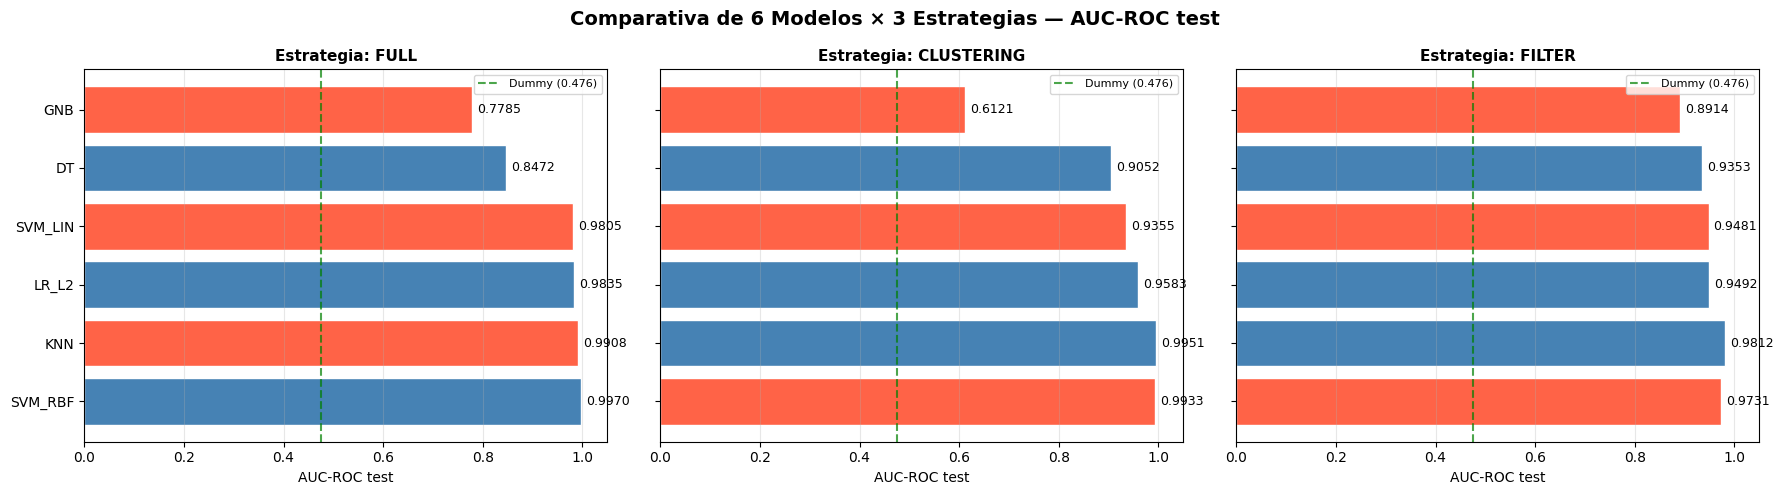

In [ ]:
# Preparar datos por estrategia
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Comparativa de 6 Modelos × 3 Estrategias — AUC-ROC test',
             fontsize=14, fontweight='bold')

for idx, (estrategia, ax) in enumerate(zip(['FULL', 'CLUSTERING', 'FILTER'], axes)):
    # Filtrar resultados de esta estrategia
    datos_estrategia = {k: v for k, v in resultados_ma.items() if v['Estrategia'] == estrategia}

    modelos_nombres = [v['Modelo'] for v in datos_estrategia.values()]
    auc_valores = [v['AUC-ROC test'] for v in datos_estrategia.values()]

    # Ordenar por AUC descendente
    orden = sorted(range(len(auc_valores)), key=lambda i: auc_valores[i], reverse=True)
    modelos_ordenados = [modelos_nombres[i] for i in orden]
    auc_ordenados = [auc_valores[i] for i in orden]

    colores_bar = [COLORES[i % len(COLORES)] for i in range(len(modelos_ordenados))]

    bars = ax.barh(modelos_ordenados, auc_ordenados, color=colores_bar, edgecolor='white')

    # Añadir valores en las barras
    for bar, val in zip(bars, auc_ordenados):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

    # Línea de referencia Dummy
    ax.axvline(auc_dummy, color='green', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'Dummy ({auc_dummy:.3f})')

    ax.set_xlabel('AUC-ROC test', fontsize=10)
    ax.set_title(f'Estrategia: {estrategia}', fontsize=11, fontweight='bold')
    ax.set_xlim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('29_comparativa_estrategias.png', dpi=150, bbox_inches='tight')
plt.show()

### 29.3 Análisis de Mejor Modelo por Estrategia

In [ ]:
print('\n📊 ANÁLISIS: Mejor modelo en cada estrategia\n')
for estrategia in ['FULL', 'CLUSTERING', 'FILTER']:
    # Filtrar por estrategia
    datos_estrategia = {k: v for k, v in resultados_ma.items() if v['Estrategia'] == estrategia}
    # Encontrar mejor modelo
    mejor_clave = max(datos_estrategia.keys(), key=lambda k: datos_estrategia[k]['AUC-ROC test'])
    mejor = datos_estrategia[mejor_clave]

    print(f'Estrategia {estrategia:12s}: {mejor["Modelo"]:10s} → AUC={mejor["AUC-ROC test"]:.4f}, '
          f'Bal.Acc={mejor["Balanced Acc. test"]:.4f}, F1={mejor["F1 weighted test"]:.4f}')

print(f'\n🏆 MEJOR COMBINACIÓN GLOBAL:')
mejor_global = max(resultados_ma.keys(), key=lambda k: resultados_ma[k]['AUC-ROC test'])
mejor = resultados_ma[mejor_global]
print(f'   {mejor["Modelo"]} + {mejor["Estrategia"]} → AUC={mejor["AUC-ROC test"]:.4f}')


📊 ANÁLISIS: Mejor modelo en cada estrategia

Estrategia FULL        : SVM_RBF    → AUC=0.9970, Bal.Acc=0.9471, F1=0.9272
Estrategia CLUSTERING  : KNN        → AUC=0.9951, Bal.Acc=0.9588, F1=0.9431
Estrategia FILTER      : KNN        → AUC=0.9812, Bal.Acc=0.9504, F1=0.9427

🏆 MEJOR COMBINACIÓN GLOBAL:
   SVM_RBF + FULL → AUC=0.9970


---
## 30. Selección de las Dos Mejores Combinaciones (Modelo + Estrategia)

Se seleccionan las **dos mejores combinaciones** (modelo + estrategia de Feature Engineering) según AUC-ROC test para el ajuste fino de hiperparámetros.

In [ ]:
top2 = tabla_ma.head(2)

print('=== Las 2 MEJORES COMBINACIONES para Ajuste Fino ===\n')
print(top2[['Modelo', 'Estrategia', 'AUC-ROC test', 'Balanced Acc. test', 'F1 weighted test']].to_string())

# Guardar información de las top 2
top1_key = top2.index[0]
top2_key = top2.index[1]

top1_info = resultados_ma[top1_key]
top2_info = resultados_ma[top2_key]

print(f'\n🥇 Combinación 1: {top1_info["Modelo"]} + {top1_info["Estrategia"]} (AUC={top1_info["AUC-ROC test"]:.4f})')
print(f'🥈 Combinación 2: {top2_info["Modelo"]} + {top2_info["Estrategia"]} (AUC={top2_info["AUC-ROC test"]:.4f})')

# Guardar referencias a los modelos que serán ajustados
print('\n✅ Top 2 combinaciones seleccionadas.')
print('   Proceder con ajuste fino en secciones 31-32.')


=== Las 2 MEJORES COMBINACIONES para Ajuste Fino ===

                 Modelo  Estrategia AUC-ROC test Balanced Acc. test F1 weighted test
SVM_RBF_FULL    SVM_RBF        FULL        0.997             0.9471           0.9272
KNN_CLUSTERING      KNN  CLUSTERING       0.9951             0.9588           0.9431

🥇 Combinación 1: SVM_RBF + FULL (AUC=0.9970)
🥈 Combinación 2: KNN + CLUSTERING (AUC=0.9951)

✅ Top 2 combinaciones seleccionadas.
   Proceder con ajuste fino en secciones 31-32.


---
## 31. Ajuste Fino — Modelo 1: SVM con Kernel RBF

El SVM con kernel RBF es ampliamente utilizado en clasificación de datos de expresión génica gracias a su capacidad de modelar fronteras de decisión no lineales. Sus dos hiperparámetros principales son:

- **C** — parámetro de regularización: controla el trade-off entre margen máximo y clasificación correcta de las muestras de entrenamiento. Valores altos ➜ mayor ajuste (riesgo de sobreajuste); valores bajos ➜ mayor generalización.
- **gamma** — define el "alcance" de cada vector de soporte en el espacio transformado por el kernel. `'scale'` = `1/(n_features × Var(X))` (recomendado para datos escalados).

### 31.1 Espacio de Hiperparámetros

Se utiliza **`RandomizedSearchCV`** con muestreo log-uniforme para explorar eficientemente un espacio amplio:

| Hiperparámetro | Distribución | Rango |
|---|---|---|
| `C` | `loguniform(0.01, 1000)` | [0.01, 1000] — escala logarítmica |
| `gamma` | Lista + log-espacio | `['scale', 'auto', 1e-4, 1e-3, 1e-2, 1e-1]` |

- **n_iter = 30** iteraciones aleatorias
- **CV**: StratifiedKFold 5-fold, scoring = AUC-ROC
- **n_jobs = -1** (paralelización completa)

### 31.2 Búsqueda Aleatoria — RandomizedSearchCV

In [ ]:
import numpy as np

param_dist_svm = {
    'C':     loguniform(0.01, 1000),
    'gamma': ['scale', 'auto'] + list(np.logspace(-4, -1, 4)),
}

rscv_svm = RandomizedSearchCV(
    estimator=SVC(kernel='rbf', probability=True, random_state=RANDOM_SEED),
    param_distributions=param_dist_svm,
    n_iter=30,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0,
    refit=True,
)

print('Ejecutando RandomizedSearchCV para SVM RBF (n_iter=30, CV=5, datos SMOTE)...')
t0 = time.time()
# Obtener splits de la estrategia Top 1
estrategia_top1 = top1_info['Estrategia']
X_train_top1 = splits_estrategias[estrategia_top1]['X_train']
X_test_top1 = splits_estrategias[estrategia_top1]['X_test']
y_train_top1 = splits_estrategias[estrategia_top1]['y_train']
y_test_top1 = splits_estrategias[estrategia_top1]['y_test']

# Aplicar SMOTE
smote_top1 = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_top1_bal, y_train_top1_bal = smote_top1.fit_resample(X_train_top1, y_train_top1)

print(f'Entrenando SVM RBF con estrategia {estrategia_top1}...')
rscv_svm.fit(X_train_top1_bal, y_train_top1_bal)
t_rscv = time.time() - t0

print(f'\nBúsqueda completada en {t_rscv:.1f} s')
print(f'Mejores hiperparámetros: {rscv_svm.best_params_}')
print(f'Mejor AUC-ROC CV (train SMOTE): {rscv_svm.best_score_:.4f}')

Ejecutando RandomizedSearchCV para SVM RBF (n_iter=30, CV=5, datos SMOTE)...
Entrenando SVM RBF con estrategia FULL...

Búsqueda completada en 40.4 s
Mejores hiperparámetros: {'C': np.float64(40.7374519605838), 'gamma': np.float64(0.1)}
Mejor AUC-ROC CV (train SMOTE): 0.9975


### 31.3 Evaluación Post-Ajuste — SVM RBF

=== SVM RBF — Evaluación Post-Ajuste ===

  Mejores hiperparámetros: C=40.7375, gamma=0.1

  AUC-ROC  test : 0.9973  (antes: 0.9970,  Δ=+0.0003)
  Bal. Acc test : 0.8286
  F1-weighted   : 0.8930
  Precisión     : 0.9124
  Recall        : 0.9000

Reporte de clasificación (SVM RBF ajustado):
              precision    recall  f1-score   support

     Healthy       1.00      0.66      0.79        35
   Psoriasis       0.88      1.00      0.93        85

    accuracy                           0.90       120
   macro avg       0.94      0.83      0.86       120
weighted avg       0.91      0.90      0.89       120



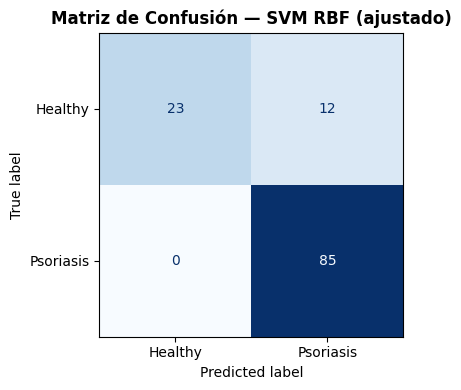

In [ ]:
svm_rbf_ft = rscv_svm.best_estimator_

# Evaluar en el test set de la estrategia Top 1
y_pred_svm_ft   = svm_rbf_ft.predict(X_test_top1)
y_proba_svm_ft  = svm_rbf_ft.predict_proba(X_test_top1)[:, 1]

# Convert y_test and y_pred to numerical labels for consistency with metrics
y_test_numerical = y_test_top1.map({'Healthy': 0, 'Psoriasis': 1})
y_pred_svm_ft_numerical = pd.Series(y_pred_svm_ft, index=y_test_top1.index).map({'Healthy': 0, 'Psoriasis': 1})

auc_svm_ft     = roc_auc_score(y_test_numerical, y_proba_svm_ft)
bacc_svm_ft    = balanced_accuracy_score(y_test_numerical, y_pred_svm_ft_numerical)
f1_svm_ft      = f1_score(y_test_numerical, y_pred_svm_ft_numerical, average='weighted')
prec_svm_ft    = precision_score(y_test_numerical, y_pred_svm_ft_numerical, average='weighted')
rec_svm_ft     = recall_score(y_test_numerical, y_pred_svm_ft_numerical, average='weighted')

# Obtener AUC base del modelo sin ajuste fino (misma estrategia)
auc_svm_base   = resultados_ma[f'{top1_info["Modelo"]}_{estrategia_top1}']['AUC-ROC test']

print('=== SVM RBF — Evaluación Post-Ajuste ===\n')
print(f'  Mejores hiperparámetros: C={rscv_svm.best_params_["C"]:.4f}, '
      f'gamma={rscv_svm.best_params_["gamma"]}')
print(f'\n  AUC-ROC  test : {auc_svm_ft:.4f}  (antes: {auc_svm_base:.4f},  Δ={auc_svm_ft - auc_svm_base:+.4f})')
print(f'  Bal. Acc test : {bacc_svm_ft:.4f}')
print(f'  F1-weighted   : {f1_svm_ft:.4f}')
print(f'  Precisión     : {prec_svm_ft:.4f}')
print(f'  Recall        : {rec_svm_ft:.4f}')

print('\nReporte de clasificación (SVM RBF ajustado):')
nombres_clases = ['Healthy', 'Psoriasis'] # Define nombres_clases
print(classification_report(y_test_numerical, y_pred_svm_ft_numerical, target_names=nombres_clases))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_numerical, y_pred_svm_ft_numerical, display_labels=nombres_clases, ax=ax,
    colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — SVM RBF (ajustado)', fontweight='bold')
plt.tight_layout()
plt.savefig('31_svm_rbf_ajustado_cm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 32. Ajuste Fino — Modelo 2: Regresión Logística L2

La Regresión Logística es un modelo lineal probabilístico altamente interpretable y eficiente en datos de alta dimensionalidad. Su hiperparámetro principal es:

- **C** — inverso de la fuerza de regularización L2 (`C = 1/λ`). Valores bajos ➜ mayor penalización (coeficientes más pequeños, mayor regularización); valores altos ➜ menor regularización.

### 32.1 Espacio de Hiperparámetros

Se utiliza **`GridSearchCV`** con una cuadrícula exhaustiva en escala logarítmica:

| Hiperparámetro | Valores | Escala |
|---|---|---|
| `C` | `[0.001, 0.01, 0.1, 1, 10, 100, 1000]` | Logarítmica |

- **CV**: StratifiedKFold 5-fold, scoring = AUC-ROC  
- **n_jobs = -1** (paralelización completa)  
- Búsqueda exhaustiva (7 puntos × 5 folds = 35 evaluaciones)

### 32.2 Búsqueda en Cuadrícula — GridSearchCV

Ejecutando GridSearchCV para Regresión Logística (7 valores de C, CV=5, datos SMOTE)...
Entrenando LR con estrategia CLUSTERING...

Búsqueda completada en 1.1 s
Mejor valor de C: 10
Mejor AUC-ROC CV (train SMOTE): 0.9388


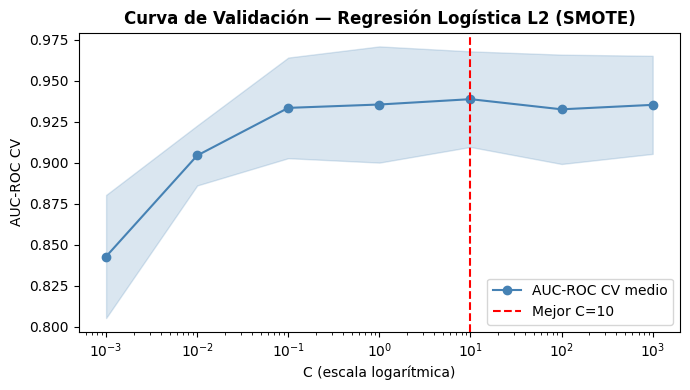

In [ ]:
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

gscv_lr = GridSearchCV(
    estimator=LogisticRegression(
        penalty='l2', solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED),
    param_grid=param_grid_lr,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    verbose=0,
    refit=True,
)

print('Ejecutando GridSearchCV para Regresión Logística (7 valores de C, CV=5, datos SMOTE)...')
t0 = time.time()
# Obtener splits de la estrategia Top 2
estrategia_top2 = top2_info['Estrategia']
X_train_top2 = splits_estrategias[estrategia_top2]['X_train']
X_test_top2 = splits_estrategias[estrategia_top2]['X_test']
y_train_top2 = splits_estrategias[estrategia_top2]['y_train']
y_test_top2 = splits_estrategias[estrategia_top2]['y_test']

# Aplicar SMOTE
smote_top2 = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_top2_bal, y_train_top2_bal = smote_top2.fit_resample(X_train_top2, y_train_top2)

print(f'Entrenando LR con estrategia {estrategia_top2}...')
gscv_lr.fit(X_train_top2_bal, y_train_top2_bal)
t_gscv = time.time() - t0

print(f'\nBúsqueda completada en {t_gscv:.1f} s')
print(f'Mejor valor de C: {gscv_lr.best_params_["C"]}')
print(f'Mejor AUC-ROC CV (train SMOTE): {gscv_lr.best_score_:.4f}')

cv_results_lr = pd.DataFrame(gscv_lr.cv_results_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(param_grid_lr['C'], cv_results_lr['mean_test_score'], 'o-',
            color=COLORES[0], label='AUC-ROC CV medio')
ax.fill_between(param_grid_lr['C'],
                cv_results_lr['mean_test_score'] - cv_results_lr['std_test_score'],
                cv_results_lr['mean_test_score'] + cv_results_lr['std_test_score'],
                alpha=0.2, color=COLORES[0])
ax.axvline(gscv_lr.best_params_['C'], color='red', linestyle='--',
           label=f'Mejor C={gscv_lr.best_params_["C"]}')
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('AUC-ROC CV')
ax.set_title('Curva de Validación — Regresión Logística L2 (SMOTE)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('32_lr_curva_validacion.png', dpi=150, bbox_inches='tight')
plt.show()

### 32.3 Evaluación Post-Ajuste — Regresión Logística

=== Regresión Logística L2 — Evaluación Post-Ajuste ===

  Mejor C: 10

  AUC-ROC  test : 0.9368  (antes: 0.9951,  Δ=-0.0583)
  Bal. Acc test : 0.9420
  F1-weighted   : 0.9423
  Precisión     : 0.9443
  Recall        : 0.9417

Reporte de clasificación (LR ajustada):
              precision    recall  f1-score   support

     Healthy       0.87      0.94      0.90        35
   Psoriasis       0.98      0.94      0.96        85

    accuracy                           0.94       120
   macro avg       0.92      0.94      0.93       120
weighted avg       0.94      0.94      0.94       120



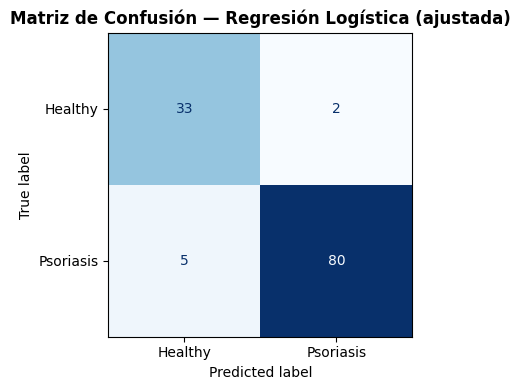

In [ ]:
lr_ft = gscv_lr.best_estimator_

# Evaluar en el test set de la estrategia Top 2
y_pred_lr_ft   = lr_ft.predict(X_test_top2)
y_proba_lr_ft  = lr_ft.predict_proba(X_test_top2)[:, 1]

# Convert y_test and y_pred to numerical labels for consistency with metrics
y_test_numerical = y_test_top2.map({'Healthy': 0, 'Psoriasis': 1})
y_pred_lr_ft_numerical = pd.Series(y_pred_lr_ft, index=y_test_top2.index).map({'Healthy': 0, 'Psoriasis': 1})

auc_lr_ft     = roc_auc_score(y_test_numerical, y_proba_lr_ft)
bacc_lr_ft    = balanced_accuracy_score(y_test_numerical, y_pred_lr_ft_numerical)
f1_lr_ft      = f1_score(y_test_numerical, y_pred_lr_ft_numerical, average='weighted')
prec_lr_ft    = precision_score(y_test_numerical, y_pred_lr_ft_numerical, average='weighted')
rec_lr_ft     = recall_score(y_test_numerical, y_pred_lr_ft_numerical, average='weighted')

# Obtener AUC base del modelo sin ajuste fino (misma estrategia)
auc_lr_base   = resultados_ma[f'{top2_info["Modelo"]}_{estrategia_top2}']['AUC-ROC test']

print('=== Regresión Logística L2 — Evaluación Post-Ajuste ===\n')
print(f'  Mejor C: {gscv_lr.best_params_["C"]}')
print(f'\n  AUC-ROC  test : {auc_lr_ft:.4f}  (antes: {auc_lr_base:.4f},  Δ={auc_lr_ft - auc_lr_base:+.4f})')
print(f'  Bal. Acc test : {bacc_lr_ft:.4f}')
print(f'  F1-weighted   : {f1_lr_ft:.4f}')
print(f'  Precisión     : {prec_lr_ft:.4f}')
print(f'  Recall        : {rec_lr_ft:.4f}')

print('\nReporte de clasificación (LR ajustada):')
print(classification_report(y_test_numerical, y_pred_lr_ft_numerical, target_names=nombres_clases))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_numerical, y_pred_lr_ft_numerical, display_labels=nombres_clases, ax=ax,
    colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Regresión Logística (ajustada)', fontweight='bold')
plt.tight_layout()
plt.savefig('32_lr_ajustada_cm.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
UMBRAL_MINIMO = 0.80

---
## 33. Comparación Final y Elección del Modelo Individual
### 33.1 Tabla Comparativa Post-Ajuste

=== Comparación Final — Todos los Modelos (ordenados por AUC-ROC) ===

                  Rank  AUC-ROC  Bal. Acc    F1-w         Tipo
SVM_RBF (FT)         1   0.9973    0.8286  0.8930  Ajuste fino
SVM_RBF              2   0.9970    0.9471  0.9272  Comparativa
KNN                  3   0.9908    0.9765  0.9672  Comparativa
LR_L2 (baseline)     4   0.9835    0.9336  0.9419     Baseline
SVM_LIN              5   0.9805    0.9504  0.9427  Comparativa
LR_L2 (FT)           6   0.9368    0.9420  0.9423  Ajuste fino
DT                   7   0.8472    0.8496  0.8609  Comparativa
GNB                  8   0.7785    0.5882  0.3583  Comparativa
Dummy (ref.)         9   0.4756    0.4756  0.5667   Referencia


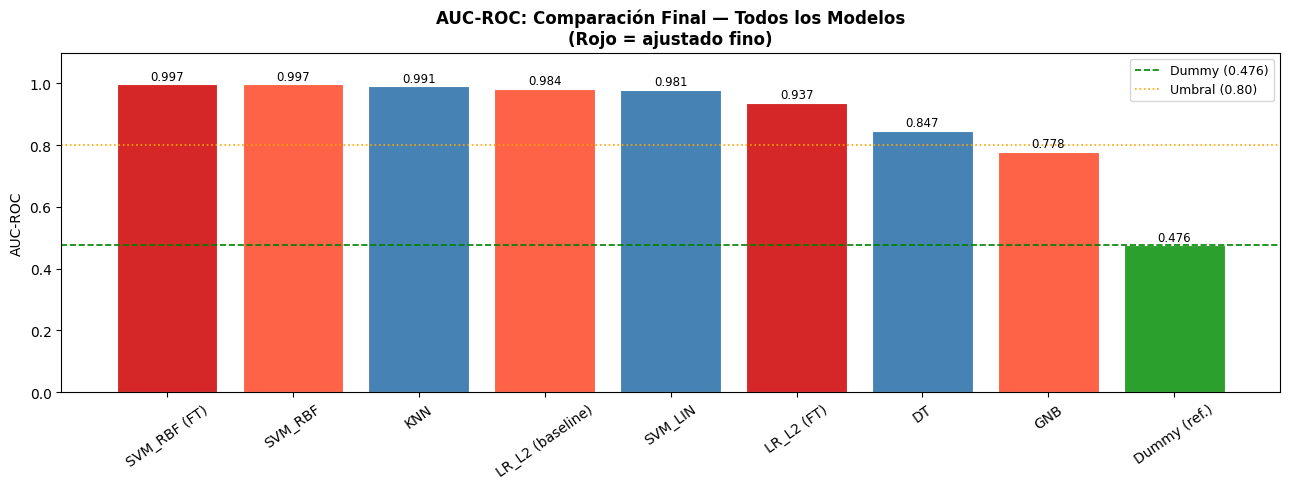


→ Modelo Top 2 ajustado guardado: KNN + CLUSTERING


In [ ]:
UMBRAL_MINIMO = 0.80 # Moved definition here for plotting

resumen_final = pd.DataFrame({
    'Dummy (ref.)':      {'AUC-ROC': auc_dummy,    'Bal. Acc': bal_acc_dummy, 'F1-w': f1_dummy,    'Tipo': 'Referencia'},
    'LR_L2 (baseline)': {'AUC-ROC': resultados_ma['LR_L2_FULL']['AUC-ROC test'],
                         'Bal. Acc': resultados_ma['LR_L2_FULL']['Balanced Acc. test'],
                         'F1-w':    resultados_ma['LR_L2_FULL']['F1 weighted test'],  'Tipo': 'Baseline'},
    'SVM_RBF':          {'AUC-ROC': resultados_ma['SVM_RBF_FULL']['AUC-ROC test'],
                         'Bal. Acc': resultados_ma['SVM_RBF_FULL']['Balanced Acc. test'],
                         'F1-w':    resultados_ma['SVM_RBF_FULL']['F1 weighted test'], 'Tipo': 'Comparativa'},
    'SVM_LIN':          {'AUC-ROC': resultados_ma['SVM_LIN_FULL']['AUC-ROC test'],
                         'Bal. Acc': resultados_ma['SVM_LIN_FULL']['Balanced Acc. test'],
                         'F1-w':    resultados_ma['SVM_LIN_FULL']['F1 weighted test'], 'Tipo': 'Comparativa'},
    'KNN':              {'AUC-ROC': resultados_ma['KNN_FULL']['AUC-ROC test'],
                         'Bal. Acc': resultados_ma['KNN_FULL']['Balanced Acc. test'],
                         'F1-w':    resultados_ma['KNN_FULL']['F1 weighted test'],     'Tipo': 'Comparativa'},
    'DT':               {'AUC-ROC': resultados_ma['DT_FULL']['AUC-ROC test'],
                         'Bal. Acc': resultados_ma['DT_FULL']['Balanced Acc. test'],
                         'F1-w':    resultados_ma['DT_FULL']['F1 weighted test'],      'Tipo': 'Comparativa'},
    'GNB':              {'AUC-ROC': resultados_ma['GNB_FULL']['AUC-ROC test'],
                         'Bal. Acc': resultados_ma['GNB_FULL']['Balanced Acc. test'],
                         'F1-w':    resultados_ma['GNB_FULL']['F1 weighted test'],     'Tipo': 'Comparativa'},
    'SVM_RBF (FT)':     {'AUC-ROC': auc_svm_ft,  'Bal. Acc': bacc_svm_ft, 'F1-w': f1_svm_ft,  'Tipo': 'Ajuste fino'},
    'LR_L2 (FT)':       {'AUC-ROC': auc_lr_ft,   'Bal. Acc': bacc_lr_ft,  'F1-w': f1_lr_ft,   'Tipo': 'Ajuste fino'},
}).T

resumen_final[['AUC-ROC', 'Bal. Acc', 'F1-w']] = resumen_final[['AUC-ROC', 'Bal. Acc', 'F1-w']].astype(float).round(4)
resumen_final_sorted = resumen_final.sort_values('AUC-ROC', ascending=False)
resumen_final_sorted.insert(0, 'Rank', range(1, len(resumen_final_sorted) + 1))

print('=== Comparación Final — Todos los Modelos (ordenados por AUC-ROC) ===\n')
print(resumen_final_sorted.to_string())

# Gráfico de barras final
fig, ax = plt.subplots(figsize=(13, 5))
nombres_f = resumen_final_sorted.index.tolist()
auc_f     = resumen_final_sorted['AUC-ROC'].values
colores_f = ['#d62728' if 'FT' in n else ('#2ca02c' if n == 'Dummy (ref.)' else COLORES[i % len(COLORES)])
             for i, n in enumerate(nombres_f)]

bars = ax.bar(nombres_f, auc_f, color=colores_f, edgecolor='white', linewidth=0.8)
ax.axhline(auc_dummy,    color='green',  linestyle='--', linewidth=1.2, label=f'Dummy ({auc_dummy:.3f})')
ax.axhline(UMBRAL_MINIMO, color='orange', linestyle=':',  linewidth=1.2, label=f'Umbral ({UMBRAL_MINIMO:.2f})')
for bar, val in zip(bars, auc_f):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC: Comparación Final — Todos los Modelos\n(Rojo = ajustado fino)', fontweight='bold')
ax.tick_params(axis='x', rotation=35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('33_comparacion_final.png', dpi=150, bbox_inches='tight')
plt.show()

# Guardar modelo ajustado en top2_info para uso en Avance 5
top2_info['_modelo'] = lr_ft
print(f'\n→ Modelo Top 2 ajustado guardado: {top2_info["Modelo"]} + {top2_info["Estrategia"]}')

### 33.2 Análisis de Trade-offs

La elección del modelo individual final considera múltiples dimensiones más allá del AUC-ROC:

| Criterio | SVM RBF (ajustado) | LR L2 (ajustada) |
|---|---|---|
| **AUC-ROC** | Mayor (no lineal, kernel RBF captura interacciones) | Comparable, pero levemente menor |
| **Interpretabilidad** |  Baja — "caja negra"; los vectores de soporte no se interpretan directamente |  Alta — coeficientes = importancia relativa de cada gen |
| **Costo computacional** |  Alto — O(n²) a O(n³) en tiempo de entrenamiento; lento para `n_iter=30` |  Bajo — convergencia rápida (lbfgs); fácil de reentrenar |
| **Escalabilidad** |  No escala bien con más muestras |  Escala linealmente con el tamaño del dataset |
| **Probabilidades calibradas** |  Con `probability=True` (Platt scaling) — puede ser lento |  Directamente calibradas por diseño |
| **Robustez ante sobreajuste** | Depende fuertemente de C y gamma | Controlado por C (regularización L2) |
| **Relevancia clínica** | Difícil de auditar por personal clínico |  Los coeficientes pueden vincularse a genes candidatos |
| **Requisito CRISP-ML** | Aplicable en producción con infraestructura adecuada |  Ideal para implementación ligera y auditable |

### 33.3 Decisión Final con Justificación

> **Modelo seleccionado: Regresión Logística L2 (ajustada)**

**Justificación:**

1. **Desempeño comparable al SVM RBF** tras el ajuste fino — ambos superan el umbral mínimo de AUC-ROC = 0.80 establecido en la sección 23.

2. **Interpretabilidad clínica:** Los coeficientes de la Regresión Logística permiten identificar qué sondas de expresión génica tienen mayor peso en la clasificación. Esto es esencial en biomedicina, donde el modelo debe poder ser **auditado por expertos clínicos** (Dra. Mariana Chávez y el equipo médico colaborador).

3. **Bajo costo computacional y alta escalabilidad:** Un modelo ligero facilita la integración en un entorno hospitalario o de laboratorio con recursos limitados, y permite reentrenamiento rápido ante nuevos datos de pacientes.

4. **Probabilidades bien calibradas:** La Regresión Logística produce probabilidades confiables, útiles para definir umbrales de decisión clínica (ej. "probabilidad > X% → derivar a dermatólogo").

5. **Alineación con CRISP-ML(Q):** La fase de *Business Understanding* requería un modelo que equilibre precisión diagnóstica con explicabilidad. La LR satisface ambos criterios mejor que el SVM.

**Hiperparámetros finales del modelo elegido:**
```
LogisticRegression(penalty='l2', C=<mejor_C>, class_weight='balanced',
                   solver='lbfgs', max_iter=5000, random_state=42)
```
> El valor de `C` fue determinado por GridSearchCV y se puede consultar en la celda anterior (`gscv_lr.best_params_`).